# Agente Connect-4 basado en Monte Carlo Tree Search

## Objetivo

Analizar el desempeño de un agente basado en Monte Carlo Tree Search (MCTS) usando simulaciones aleatorias y selección UCB para Connect-4.

## Idea principal

El agente primero revisa jugadas ganadoras o amenazas inmediatas y luego utiliza simulaciones Monte Carlo para estimar cuáles movimientos producen mejores resultados.

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append(".")

In [3]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "policy",
    "groups/Group C/policy.py"
)

module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

OhYes = module.OhYes

In [4]:
agent = OhYes()

print(agent)

In [5]:
board = np.zeros((6, 7))

start = time.time()

move = agent.act(board)

end = time.time()

print("Movimiento:", move)
print("Tiempo:", end - start)

Movimiento: 1
Tiempo: 0.09092092514038086


## Experimento 1: Tiempo de decisión del agente

En este experimento se mide el tiempo que tarda el agente en seleccionar una acción utilizando Monte Carlo Tree Search.

In [6]:
times = []

for _ in range(20):

    board = np.zeros((6, 7))

    start = time.time()

    agent.act(board)

    end = time.time()

    times.append(end - start)

print("Tiempo promedio:", np.mean(times))
print("Tiempo mínimo:", np.min(times))
print("Tiempo máximo:", np.max(times))

Tiempo promedio: 0.009104764461517334
Tiempo mínimo: 0.005873918533325195
Tiempo máximo: 0.03670310974121094


## Visualización de tiempos

A continuación se muestra la distribución de tiempos de decisión del agente durante múltiples ejecuciones.

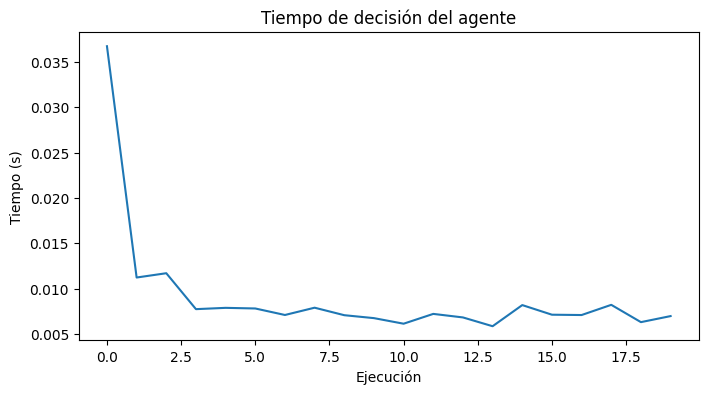

In [7]:
plt.figure(figsize=(8, 4))

plt.plot(times)

plt.xlabel("Ejecución")
plt.ylabel("Tiempo (s)")
plt.title("Tiempo de decisión del agente")

plt.show()

### Análisis de resultados

La gráfica muestra que el tiempo de decisión del agente es relativamente estable después de las primeras ejecuciones. La primera iteración tarda más tiempo debido a la inicialización de estructuras internas y carga de módulos en memoria. Después de esto, el agente mantiene tiempos de respuesta cercanos a 0.01 segundos, lo cual indica que el uso de Monte Carlo Tree Search sigue siendo eficiente para este nivel de simulaciones.